# Sesión 2: Matemáticas para Machine Learning I
## Geometría de los datos

**Curso:** Diseño de Experimentos Avanzado 

**Duración:** 1.5 horas

**Objetivos**

Al finalizar esta sesión el estudiante será capaz de:

1. Representar observaciones como vectores en $\mathbb{R}^n$ y operar con ellos.
2. Calcular normas L1, L2 y L$\infty$ e interpretar su significado geométrico.
3. Calcular distancias Euclidiana, Manhattan y coseno entre observaciones.
4. Interpretar el producto punto como medida de similitud angular.
5. Representar una base de datos como matriz $X \in \mathbb{R}^{n \times p}$.
6. Aplicar transformaciones lineales y escalamiento de variables.
7. Comprender, implementar y validar el algoritmo k-NN para regresión y clasificación.
8. Aplicar un diseño de experimentos para seleccionar el hiperparámetro $k$ en k-NN.

## Importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11
print('Librerías cargadas.')

Librerías cargadas.


## 1. Vectores

**Definición.** El conjunto $\mathbb{R}^n$ es el espacio de todas las $n$-uplas de números reales:

$$\mathbb{R}^n = \{(x_1, x_2, \ldots, x_n) : x_i \in \mathbb{R},\ i = 1, \ldots, n\}$$

Un **vector** $x \in \mathbb{R}^n$ puede escribirse como vector columna:

$$x = \begin{pmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{pmatrix}$$

o como vector fila $x^T = (x_1, x_2, \ldots, x_n)$. El subíndice $i$ denota la $i$-ésima componente.

En machine learning, cada **observación** con $p$ variables medidas se representa como un vector
$x \in \mathbb{R}^p$. Por ejemplo, si se registran temperatura, presión y tiempo de una corrida
experimental, se tiene:

$$x = \begin{pmatrix} 200 \\ 5 \\ 30 \end{pmatrix} \in \mathbb{R}^3$$

donde las unidades de cada componente son °C, bar y min, respectivamente.

In [2]:
# Representación de vectores en NumPy
x_col = np.array([[200],
                   [5],
                   [30]])        # vector columna (3,1)

x_fila = np.array([200, 5, 30]) # vector fila (3,)

print(f'Vector columna:\n{x_col}')
print(f'Shape: {x_col.shape}\n')
print(f'Vector fila: {x_fila}')
print(f'Shape: {x_fila.shape}')
print(f'\nTranspuesta del vector fila: {x_fila.reshape(-1,1).T}')

Vector columna:
[[200]
 [  5]
 [ 30]]
Shape: (3, 1)

Vector fila: [200   5  30]
Shape: (3,)

Transpuesta del vector fila: [[200   5  30]]


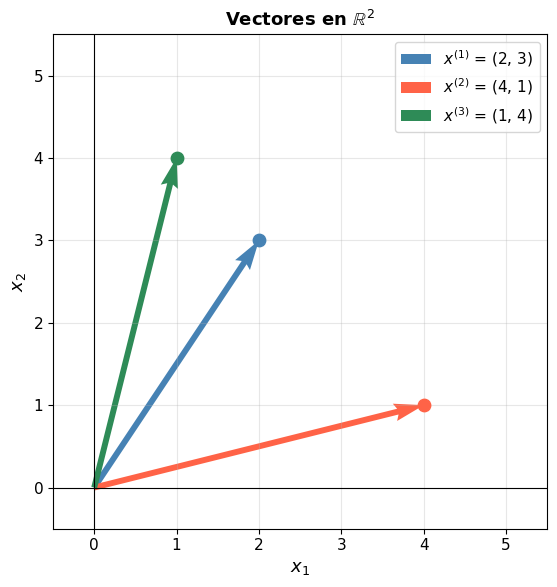

In [3]:
# Visualización de vectores en R²
fig, ax = plt.subplots(figsize=(7, 6))

vectores = {
    r'$x^{(1)}$ = (2, 3)': (np.array([2, 3]), 'steelblue'),
    r'$x^{(2)}$ = (4, 1)': (np.array([4, 1]), 'tomato'),
    r'$x^{(3)}$ = (1, 4)': (np.array([1, 4]), 'seagreen'),
}

for label, (v, c) in vectores.items():
    ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
              color=c, width=0.012, label=label)
    ax.scatter(*v, color=c, s=80, zorder=5)

ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.5, 5.5)
ax.set_xlabel('$x_1$', fontsize=13)
ax.set_ylabel('$x_2$', fontsize=13)
ax.set_title('Vectores en $\mathbb{R}^2$', fontsize=13, fontweight='bold')
ax.axhline(0, color='k', lw=0.8)
ax.axvline(0, color='k', lw=0.8)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('vectores_R2.png', dpi=200, bbox_inches='tight')
plt.show()

## 2. Operaciones con vectores

**Suma.** Dados $x, y \in \mathbb{R}^n$, la suma se define componente a componente:

$$(x + y)_i = x_i + y_i, \quad i = 1, \ldots, n$$

**Multiplicación escalar.** Para $\alpha \in \mathbb{R}$:

$$(\alpha x)_i = \alpha x_i$$

**Propiedades.** Para todo $x, y, z \in \mathbb{R}^n$ y $\alpha, \beta \in \mathbb{R}$:

- Conmutatividad: $x + y = y + x$
- Asociatividad: $(x + y) + z = x + (y + z)$
- Distributividad: $\alpha(x + y) = \alpha x + \alpha y$
- Elemento neutro: $x + 0 = x$, donde $0 = (0, \ldots, 0)^T$

In [4]:
x = np.array([3.0, -1.0,  2.0])
y = np.array([1.0,  4.0, -1.0])

print(f'x           = {x}')
print(f'y           = {y}')
print(f'x + y       = {x + y}')
print(f'x - y       = {x - y}')
print(f'2.5 * x     = {2.5 * x}')
print(f'x + y = y + x: {np.allclose(x+y, y+x)}  (conmutatividad)')

x           = [ 3. -1.  2.]
y           = [ 1.  4. -1.]
x + y       = [4. 3. 1.]
x - y       = [ 2. -5.  3.]
2.5 * x     = [ 7.5 -2.5  5. ]
x + y = y + x: True  (conmutatividad)


### Ejercicio 1

Dados los vectores $a = (2, -3, 1)^T$ y $b = (-1, 4, 2)^T$, calcule:

1. $a + b$
2. $3a - 2b$
3. Verifique que $a + b = b + a$

In [5]:
# Ejercicio 1 - SOLUCIÓN
a = np.array([2.0, -3.0, 1.0])
b = np.array([-1.0, 4.0, 2.0])

print('1. a + b =', a + b)
print('2. 3a - 2b =', 3*a - 2*b)
print('3. a + b == b + a:', np.allclose(a+b, b+a))

1. a + b = [1. 1. 3.]
2. 3a - 2b = [  8. -17.  -1.]
3. a + b == b + a: True


## 3. Normas

**Definición.** Una **norma** es una función $\|\cdot\| : \mathbb{R}^n \to \mathbb{R}_{\geq 0}$ que
satisface:

1. $\|x\| \geq 0$ y $\|x\| = 0 \Leftrightarrow x = 0$ (positividad)
2. $\|\alpha x\| = |\alpha|\,\|x\|$ (homogeneidad)
3. $\|x + y\| \leq \|x\| + \|y\|$ (desigualdad triangular)

### Norma $L_p$

La familia de normas $L_p$ para $p \geq 1$ se define como:

$$\|x\|_p = \left(\sum_{i=1}^n |x_i|^p\right)^{1/p}$$

**Norma $L_2$ (Euclidiana):** $p = 2$

$$\|x\|_2 = \sqrt{\sum_{i=1}^n x_i^2}$$

Corresponde a la longitud física del vector en el espacio.

**Norma $L_1$ (Manhattan):** $p = 1$

$$\|x\|_1 = \sum_{i=1}^n |x_i|$$

**Norma $L_\infty$:** límite cuando $p \to \infty$

$$\|x\|_\infty = \max_{i} |x_i|$$

Se puede demostrar que $\|x\|_\infty = \lim_{p\to\infty} \|x\|_p$.

**Relación entre normas.** Para todo $x \in \mathbb{R}^n$:

$$\|x\|_\infty \leq \|x\|_2 \leq \|x\|_1 \leq \sqrt{n}\,\|x\|_2$$

In [6]:
v = np.array([3.0, -4.0, 1.0])

L1   = np.linalg.norm(v, ord=1)
L2   = np.linalg.norm(v, ord=2)
Linf = np.linalg.norm(v, ord=np.inf)
L3   = np.linalg.norm(v, ord=3)

print(f'v = {v}')
print(f'||v||_1   = {L1:.4f}  (suma de |v_i|)')
print(f'||v||_2   = {L2:.4f}  (raíz de suma de v_i²)')
print(f'||v||_3   = {L3:.4f}  (norma L_p con p=3)')
print(f'||v||_inf = {Linf:.4f}  (máximo de |v_i|)')
print()
print(f'Verificación de desigualdad: {Linf:.4f} ≤ {L2:.4f} ≤ {L1:.4f}')

v = [ 3. -4.  1.]
||v||_1   = 8.0000  (suma de |v_i|)
||v||_2   = 5.0990  (raíz de suma de v_i²)
||v||_3   = 4.5144  (norma L_p con p=3)
||v||_inf = 4.0000  (máximo de |v_i|)

Verificación de desigualdad: 4.0000 ≤ 5.0990 ≤ 8.0000


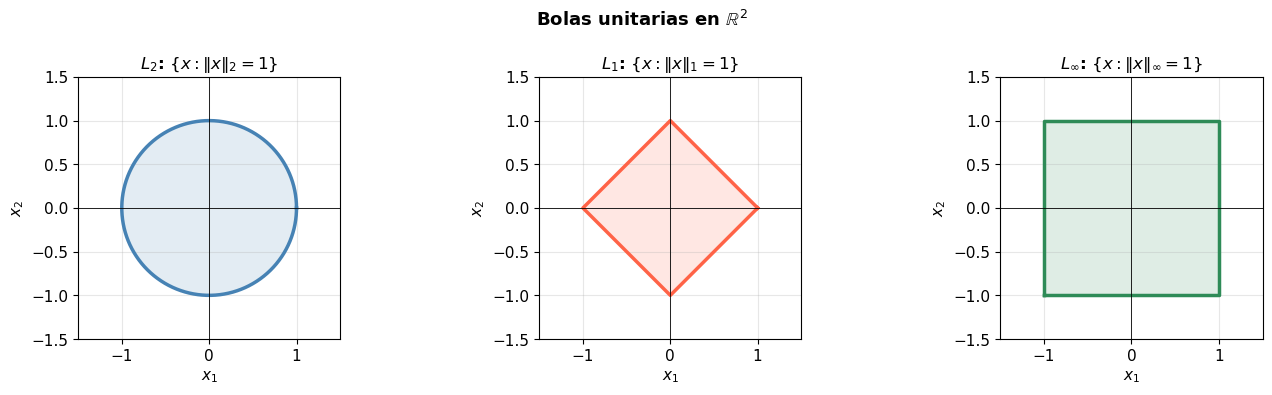

In [7]:
# Bolas unitarias: conjunto de puntos con norma = 1
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
theta = np.linspace(0, 2*np.pi, 500)

# L2: círculo
axes[0].plot(np.cos(theta), np.sin(theta), 'steelblue', lw=2.5)
axes[0].fill(np.cos(theta), np.sin(theta), alpha=0.15, color='steelblue')
axes[0].set_title('$L_2$: $\\{x : \\|x\\|_2 = 1\\}$', fontsize=12, fontweight='bold')

# L1: diamante
sq = np.array([[1,0],[0,1],[-1,0],[0,-1],[1,0]])
axes[1].plot(sq[:,0], sq[:,1], 'tomato', lw=2.5)
axes[1].fill(sq[:,0], sq[:,1], alpha=0.15, color='tomato')
axes[1].set_title('$L_1$: $\\{x : \\|x\\|_1 = 1\\}$', fontsize=12, fontweight='bold')

# Linf: cuadrado
sq2 = np.array([[-1,-1],[1,-1],[1,1],[-1,1],[-1,-1]])
axes[2].plot(sq2[:,0], sq2[:,1], 'seagreen', lw=2.5)
axes[2].fill(sq2[:,0], sq2[:,1], alpha=0.15, color='seagreen')
axes[2].set_title('$L_\\infty$: $\\{x : \\|x\\|_\\infty = 1\\}$', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_aspect('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='k', lw=0.6)
    ax.axvline(0, color='k', lw=0.6)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

plt.suptitle('Bolas unitarias en $\mathbb{R}^2$', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('normas_bolas.png', dpi=200, bbox_inches='tight')
plt.show()

### Ejercicio 2

Dado $x = (4, -3, 0, 2)^T$, calcule $\|x\|_1$, $\|x\|_2$ y $\|x\|_\infty$.
Verifique la desigualdad $\|x\|_\infty \leq \|x\|_2 \leq \|x\|_1$.

In [8]:
# Ejercicio 2 - SOLUCIÓN
x = np.array([4.0, -3.0, 0.0, 2.0])

L1   = np.linalg.norm(x, ord=1)
L2   = np.linalg.norm(x, ord=2)
Linf = np.linalg.norm(x, ord=np.inf)

print(f'x = {x}')
print(f'||x||_1   = {L1:.4f}')
print(f'||x||_2   = {L2:.4f}')
print(f'||x||_inf = {Linf:.4f}')
print(f'\nDesigualdad {Linf:.4f} ≤ {L2:.4f} ≤ {L1:.4f}: {Linf <= L2 <= L1}')

x = [ 4. -3.  0.  2.]
||x||_1   = 9.0000
||x||_2   = 5.3852
||x||_inf = 4.0000

Desigualdad 4.0000 ≤ 5.3852 ≤ 9.0000: True


## 4. Distancias

**Definición.** Una **métrica** (o función de distancia) es una función
$d : \mathbb{R}^n \times \mathbb{R}^n \to \mathbb{R}_{\geq 0}$ que satisface:

1. $d(x, y) \geq 0$ y $d(x,y) = 0 \Leftrightarrow x = y$
2. $d(x, y) = d(y, x)$ (simetría)
3. $d(x, z) \leq d(x, y) + d(y, z)$ (desigualdad triangular)

Toda norma $\|\cdot\|$ induce una métrica mediante $d(x,y) = \|x - y\|$.

### Distancia Euclidiana ($L_2$)
$$d_2(x, y) = \|x - y\|_2 = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}$$

### Distancia Manhattan ($L_1$)
$$d_1(x, y) = \|x - y\|_1 = \sum_{i=1}^n |x_i - y_i|$$

### Similitud Coseno

La similitud coseno no es una métrica en el sentido estricto, pero es ampliamente
utilizada para medir similitud direccional:

$$\text{sim}_{\cos}(x, y) = \frac{x^T y}{\|x\|_2 \|y\|_2} = \cos\theta$$

donde $\theta$ es el ángulo entre $x$ e $y$. Toma valores en $[-1, 1]$:
el valor 1 indica vectores paralelos, 0 vectores ortogonales y $-1$ vectores antiparalelos.
Se usa en recuperación de información, procesamiento de texto y sistemas de recomendación.

La distancia coseno se define como $d_{\cos}(x,y) = 1 - \text{sim}_{\cos}(x,y)$.

In [9]:
a = np.array([1.0, 2.0])
b = np.array([4.0, 6.0])

d_eucl = np.linalg.norm(a - b)
d_manh = np.linalg.norm(a - b, ord=1)
sim_cos = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
d_cos   = 1 - sim_cos
angulo  = np.degrees(np.arccos(sim_cos))

print(f'a = {a},  b = {b}')
print(f'Distancia Euclidiana d_2(a,b)  = {d_eucl:.4f}')
print(f'Distancia Manhattan  d_1(a,b)  = {d_manh:.4f}')
print(f'Similitud coseno                = {sim_cos:.4f}')
print(f'Distancia coseno                = {d_cos:.4f}')
print(f'Ángulo entre a y b              = {angulo:.2f}°')

a = [1. 2.],  b = [4. 6.]
Distancia Euclidiana d_2(a,b)  = 5.0000
Distancia Manhattan  d_1(a,b)  = 7.0000
Similitud coseno                = 0.9923
Distancia coseno                = 0.0077
Ángulo entre a y b              = 7.13°


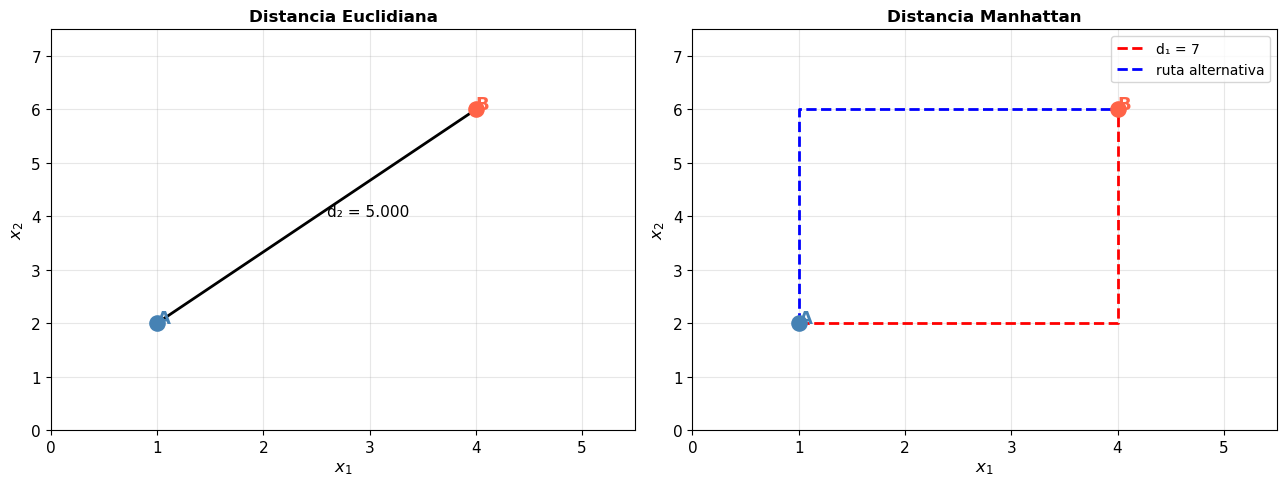

In [10]:
# Comparación geométrica: Euclidiana vs Manhattan
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

A = np.array([1.0, 2.0])
B = np.array([4.0, 6.0])

# Euclidiana
axes[0].scatter(*A, s=120, zorder=5, color='steelblue')
axes[0].scatter(*B, s=120, zorder=5, color='tomato')
axes[0].plot([A[0], B[0]], [A[1], B[1]], 'k-', lw=2)
axes[0].text((A[0]+B[0])/2+0.1, (A[1]+B[1])/2,
             f'd₂ = {np.linalg.norm(A-B):.3f}', fontsize=11)
axes[0].annotate('A', A, fontsize=13, fontweight='bold', color='steelblue',
                 xytext=(-0.3, 0), textcoords='offset points')
axes[0].annotate('B', B, fontsize=13, fontweight='bold', color='tomato',
                 xytext=(-0.3, 0), textcoords='offset points')
axes[0].set_title('Distancia Euclidiana', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 5.5)
axes[0].set_ylim(0, 7.5)

# Manhattan
axes[1].scatter(*A, s=120, zorder=5, color='steelblue')
axes[1].scatter(*B, s=120, zorder=5, color='tomato')
axes[1].plot([A[0], B[0], B[0]], [A[1], A[1], B[1]], 'r--', lw=2,
             label=f'd₁ = {np.linalg.norm(A-B, ord=1):.0f}')
axes[1].plot([A[0], A[0], B[0]], [A[1], B[1], B[1]], 'b--', lw=2,
             label='ruta alternativa')
axes[1].annotate('A', A, fontsize=13, fontweight='bold', color='steelblue')
axes[1].annotate('B', B, fontsize=13, fontweight='bold', color='tomato')
axes[1].set_title('Distancia Manhattan', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 5.5)
axes[1].set_ylim(0, 7.5)

for ax in axes:
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)

plt.tight_layout()
plt.savefig('distancias_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

### Ejercicio 3

Dados $x = (1, 0, 3)^T$ y $y = (4, 2, 1)^T$, calcule:

1. $d_2(x, y)$
2. $d_1(x, y)$
3. $\text{sim}_{\cos}(x, y)$ e interprete el resultado.

In [11]:
# Ejercicio 3 - SOLUCIÓN
x = np.array([1.0, 0.0, 3.0])
y = np.array([4.0, 2.0, 1.0])

d2  = np.linalg.norm(x - y)
d1  = np.linalg.norm(x - y, ord=1)
cos = np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

print(f'1. d_2(x,y) = {d2:.4f}')
print(f'2. d_1(x,y) = {d1:.4f}')
print(f'3. sim_cos  = {cos:.4f}  →  ángulo = {np.degrees(np.arccos(cos)):.2f}°')
print('   Interpretación: los vectores apuntan en direcciones similares (ángulo < 45°)')

1. d_2(x,y) = 4.1231
2. d_1(x,y) = 7.0000
3. sim_cos  = 0.4830  →  ángulo = 61.12°
   Interpretación: los vectores apuntan en direcciones similares (ángulo < 45°)


## 5. Producto punto y ángulo entre vectores

**Definición.** El **producto punto** (o producto interior estándar) de
$x, y \in \mathbb{R}^n$ se define como:

$$x^T y = \langle x, y \rangle = \sum_{i=1}^n x_i y_i$$

**Relación con la norma $L_2$:**

$$\|x\|_2^2 = x^T x = \sum_{i=1}^n x_i^2$$

**Relación geométrica.** El ángulo $\theta \in [0, \pi]$ entre $x$ e $y$ satisface:

$$x^T y = \|x\|_2\,\|y\|_2 \cos\theta \quad \Rightarrow \quad
\theta = \arccos\!\left(\frac{x^T y}{\|x\|_2\,\|y\|_2}\right)$$

**Interpretación:**

- $x^T y > 0 \Leftrightarrow \theta < 90°$: vectores en la misma semidirección general
- $x^T y = 0 \Leftrightarrow \theta = 90°$: vectores **ortogonales**
- $x^T y < 0 \Leftrightarrow \theta > 90°$: vectores en semidirecciones opuestas

**Aplicación en ML.** La predicción de un perceptrón lineal es:

$$\hat{y} = w^T x + b = \sum_{i=1}^p w_i x_i + b$$

que es un producto punto entre el vector de pesos $w$ y la observación $x$.

In [12]:
# Cálculo del ángulo entre dos vectores en R³
v = np.array([10.0, 9.0, 3.0])
w = np.array([2.0,  5.0, 12.0])

prod = np.dot(v, w)
norm_v = np.linalg.norm(v)
norm_w = np.linalg.norm(w)
cos_theta = prod / (norm_v * norm_w)
theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)

print(f'v = {v}')
print(f'w = {w}')
print(f'v·w          = {prod}')
print(f'||v||₂       = {norm_v:.4f}')
print(f'||w||₂       = {norm_w:.4f}')
print(f'cos(θ)       = {cos_theta:.4f}')
print(f'θ            = {theta_rad:.4f} rad  =  {theta_deg:.2f}°')

v = [10.  9.  3.]
w = [ 2.  5. 12.]
v·w          = 101.0
||v||₂       = 13.7840
||w||₂       = 13.1529
cos(θ)       = 0.5571
θ            = 0.9799 rad  =  56.15°


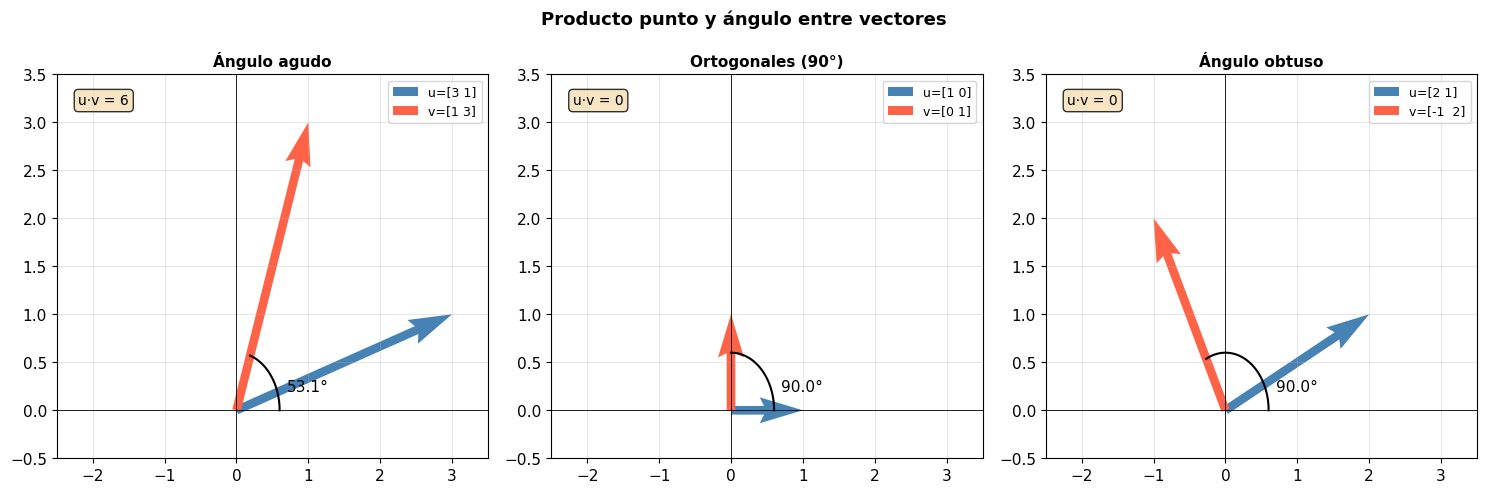

In [13]:
# Visualización del ángulo en R²
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pares = [
    (np.array([3,1]), np.array([1,3]),  'Ángulo agudo'),
    (np.array([1,0]), np.array([0,1]),  'Ortogonales (90°)'),
    (np.array([2,1]), np.array([-1,2]), 'Ángulo obtuso'),
]

for ax, (u, v, titulo) in zip(axes, pares):
    cos_uv = np.dot(u,v) / (np.linalg.norm(u)*np.linalg.norm(v))
    ang    = np.degrees(np.arccos(np.clip(cos_uv,-1,1)))

    ax.quiver(0,0,u[0],u[1], angles='xy', scale_units='xy', scale=1,
              color='steelblue', width=0.02, label=f'u={u}')
    ax.quiver(0,0,v[0],v[1], angles='xy', scale_units='xy', scale=1,
              color='tomato',    width=0.02, label=f'v={v}')

    arc_t  = np.linspace(0, np.arctan2(v[1],v[0]), 60)
    ax.plot(0.6*np.cos(arc_t), 0.6*np.sin(arc_t), 'k-', lw=1.5)
    ax.text(0.7, 0.2, f'{ang:.1f}°', fontsize=11)

    ax.text(0.05, 0.95, f'u·v = {np.dot(u,v)}', transform=ax.transAxes,
            fontsize=10, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    ax.set_xlim(-2.5, 3.5)
    ax.set_ylim(-0.5, 3.5)
    ax.axhline(0, color='k', lw=0.6)
    ax.axvline(0, color='k', lw=0.6)
    ax.grid(True, alpha=0.3)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Producto punto y ángulo entre vectores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('producto_punto_angulos.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Matrices como bases de datos

**Definición.** Una **matriz** $A \in \mathbb{R}^{m \times n}$ es un arreglo rectangular de
$m$ filas y $n$ columnas. El elemento en la fila $i$ y columna $j$ se denota $a_{ij}$ o $A_{ij}$.

En machine learning, un conjunto de $n$ observaciones con $p$ variables se organiza como:

$$X = \begin{pmatrix}
x_{11} & x_{12} & \cdots & x_{1p} \\
x_{21} & x_{22} & \cdots & x_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \cdots & x_{np}
\end{pmatrix} \in \mathbb{R}^{n \times p}$$

donde la $i$-ésima fila $x^{(i)} \in \mathbb{R}^p$ es la $i$-ésima observación,
y la $j$-ésima columna contiene todos los valores de la $j$-ésima variable.

**Producto matricial.** Si $A \in \mathbb{R}^{m \times k}$ y $B \in \mathbb{R}^{k \times n}$,
el producto $C = AB \in \mathbb{R}^{m \times n}$ se define como:

$$C_{ij} = \sum_{l=1}^k A_{il} B_{lj}$$

**Transpuesta.** La transpuesta $A^T \in \mathbb{R}^{n \times m}$ satisface $(A^T)_{ij} = A_{ji}$.

En DOE, la **matriz de diseño** tiene exactamente esta estructura: $n$ corridas
experimentales (filas) y $p$ factores (columnas).

In [14]:
# Matriz de diseño factorial 2³
X_diseno = np.array([
    [-1, -1, -1],
    [ 1, -1, -1],
    [-1,  1, -1],
    [ 1,  1, -1],
    [-1, -1,  1],
    [ 1, -1,  1],
    [-1,  1,  1],
    [ 1,  1,  1],
])

df = pd.DataFrame(X_diseno,
                  columns=['Factor A', 'Factor B', 'Factor C'],
                  index=[f'Corrida {i+1}' for i in range(8)])
print('Matriz de diseño factorial 2³ (variables codificadas):')
print(df)
print(f'\nDimensiones: {X_diseno.shape}  →  {X_diseno.shape[0]} corridas × {X_diseno.shape[1]} factores')
print(f'Rango de la matriz: {np.linalg.matrix_rank(X_diseno)}')
print()
print('Transpuesta (factores × corridas):')
print(X_diseno.T)

Matriz de diseño factorial 2³ (variables codificadas):
           Factor A  Factor B  Factor C
Corrida 1        -1        -1        -1
Corrida 2         1        -1        -1
Corrida 3        -1         1        -1
Corrida 4         1         1        -1
Corrida 5        -1        -1         1
Corrida 6         1        -1         1
Corrida 7        -1         1         1
Corrida 8         1         1         1

Dimensiones: (8, 3)  →  8 corridas × 3 factores
Rango de la matriz: 3

Transpuesta (factores × corridas):
[[-1  1 -1  1 -1  1 -1  1]
 [-1 -1  1  1 -1 -1  1  1]
 [-1 -1 -1 -1  1  1  1  1]]


## 7. Transformaciones lineales

**Definición.** Una función $T : \mathbb{R}^n \to \mathbb{R}^m$ es **lineal** si:

1. $T(x + y) = T(x) + T(y)$ para todo $x, y \in \mathbb{R}^n$
2. $T(\alpha x) = \alpha T(x)$ para todo $\alpha \in \mathbb{R}$

Toda transformación lineal puede representarse mediante una matriz $A \in \mathbb{R}^{m \times n}$:

$$T(x) = Ax$$

**Ejemplos en ML:**

- Capa lineal de red neuronal: $z = Wx + b$, donde $W$ es la matriz de pesos
- Regresión lineal: $\hat{y} = X\beta$
- Análisis de componentes principales (PCA): $Z = XW$

Las transformaciones lineales pueden escalar, rotar, reflejar o proyectar vectores,
pero preservan el origen y las combinaciones lineales.

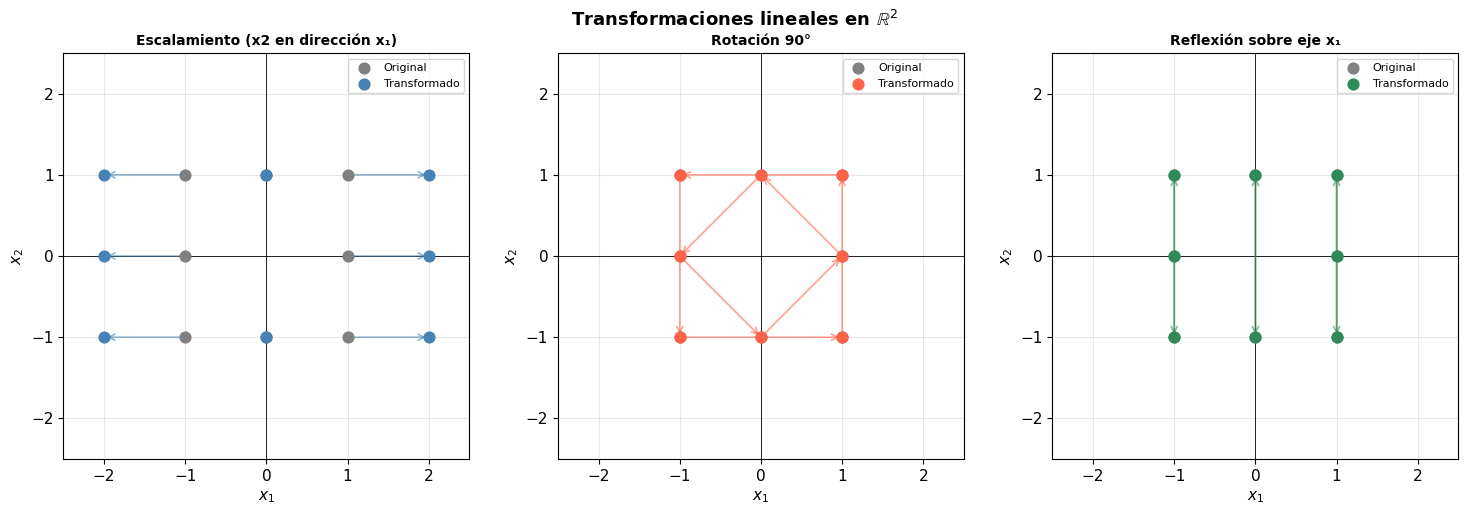

In [15]:
# Ejemplos de transformaciones lineales en R²
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

puntos = np.array([[1,0],[0,1],[1,1],[-1,1],[-1,-1],[1,-1],[0,-1],[-1,0]]).T

transformaciones = [
    (np.array([[2,0],[0,1]]),    'Escalamiento (x2 en dirección x₁)', 'steelblue'),
    (np.array([[0,-1],[1,0]]),   'Rotación 90°',                      'tomato'),
    (np.array([[1,0],[0,-1]]),   'Reflexión sobre eje x₁',            'seagreen'),
]

for ax, (A, titulo, col) in zip(axes, transformaciones):
    pts_t = A @ puntos
    ax.scatter(puntos[0], puntos[1], color='gray', s=60, label='Original', zorder=4)
    ax.scatter(pts_t[0],  pts_t[1],  color=col,   s=60, label='Transformado', zorder=4)
    for p, pt in zip(puntos.T, pts_t.T):
        ax.annotate('', xy=pt, xytext=p,
                    arrowprops=dict(arrowstyle='->', color=col, lw=1.2, alpha=0.6))
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.axhline(0, color='k', lw=0.6)
    ax.axvline(0, color='k', lw=0.6)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

plt.suptitle('Transformaciones lineales en $\mathbb{R}^2$', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('transformaciones_lineales.png', dpi=200, bbox_inches='tight')
plt.show()

## 8. Escalamiento de variables

Cuando las variables poseen unidades o rangos heterogéneos, las distancias quedan dominadas
por las variables de mayor magnitud, introduciendo un sesgo en algoritmos basados en
distancias como k-NN.

**Estandarización (Z-score).** Dado un conjunto de $n$ observaciones de la variable $j$,
con media $\mu_j$ y desviación estándar $\sigma_j$, la variable estandarizada es:

$$\tilde{x}_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

Tras la estandarización, cada variable tiene media 0 y desviación estándar 1:

$$\frac{1}{n}\sum_{i=1}^n \tilde{x}_{ij} = 0, \qquad
\frac{1}{n}\sum_{i=1}^n \tilde{x}_{ij}^2 = 1$$

**Nota.** En DOE clásico, los factores se codifican en el intervalo $[-1, +1]$,
lo cual es un caso particular de reescalamiento. La estandarización generaliza
esta idea a variables con distribuciones arbitrarias.

In [16]:
# Demostración del efecto del escalamiento en distancias
X_raw = np.array([
    [25,  5000],
    [30,  7000],
    [45,  9000],
    [28,  5500],
    [35,  8000],
], dtype=float)

nuevo_raw = np.array([[33, 6500]], dtype=float)

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_raw)
nuevo_sc = scaler.transform(nuevo_raw)

print('Datos originales (Edad | Salario):')
for i, r in enumerate(X_raw):
    d = np.linalg.norm(nuevo_raw[0] - r)
    print(f'  Obs {i+1}: {r}  →  d₂ al nuevo = {d:.2f}')

print()
print('Datos estandarizados:')
for i, r in enumerate(X_sc):
    d = np.linalg.norm(nuevo_sc[0] - r)
    print(f'  Obs {i+1}: {r.round(3)}  →  d₂ al nuevo = {d:.4f}')

print()
print('Sin escalar: la distancia está dominada por Salario (magnitud ~1000x mayor)')
print('Con escalamiento: ambas variables contribuyen equitativamente')

Datos originales (Edad | Salario):
  Obs 1: [  25. 5000.]  →  d₂ al nuevo = 1500.02
  Obs 2: [  30. 7000.]  →  d₂ al nuevo = 500.01
  Obs 3: [  45. 9000.]  →  d₂ al nuevo = 2500.03
  Obs 4: [  28. 5500.]  →  d₂ al nuevo = 1000.01
  Obs 5: [  35. 8000.]  →  d₂ al nuevo = 1500.00

Datos estandarizados:
  Obs 1: [-1.085 -1.269]  →  d₂ al nuevo = 1.5197
  Obs 2: [-0.371  0.067]  →  d₂ al nuevo = 0.5433
  Obs 3: [1.771 1.403]  →  d₂ al nuevo = 2.3930
  Obs 4: [-0.657 -0.935]  →  d₂ al nuevo = 0.9779
  Obs 5: [0.343 0.735]  →  d₂ al nuevo = 1.0421

Sin escalar: la distancia está dominada por Salario (magnitud ~1000x mayor)
Con escalamiento: ambas variables contribuyen equitativamente


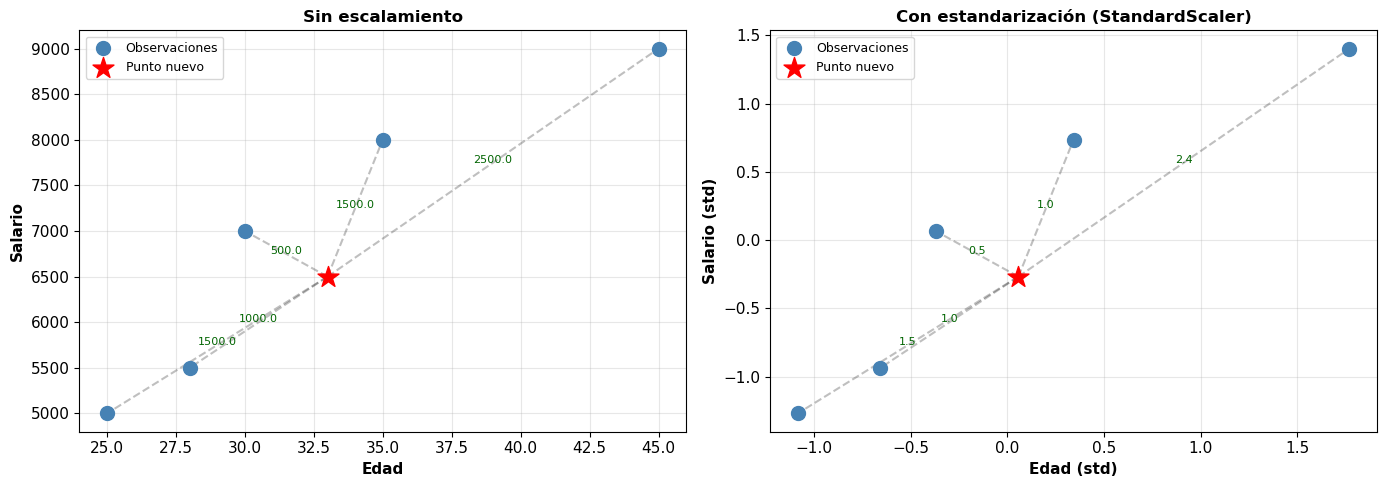

In [17]:
# Comparación visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X, nuevo, titulo, etqs in zip(
    axes,
    [X_raw, X_sc],
    [nuevo_raw[0], nuevo_sc[0]],
    ['Sin escalamiento', 'Con estandarización (StandardScaler)'],
    [['Edad', 'Salario'], ['Edad (std)', 'Salario (std)']]
):
    ax.scatter(X[:,0], X[:,1], s=100, color='steelblue', zorder=5, label='Observaciones')
    ax.scatter(nuevo[0], nuevo[1], s=250, color='red', marker='*', zorder=6, label='Punto nuevo')
    for h in X:
        d = np.linalg.norm(nuevo - h)
        ax.plot([nuevo[0], h[0]], [nuevo[1], h[1]], 'k--', alpha=0.25)
        mid = (nuevo + h) / 2
        ax.text(mid[0], mid[1], f'{d:.1f}', fontsize=8,
                ha='center', color='darkgreen')
    ax.set_xlabel(etqs[0], fontsize=11, fontweight='bold')
    ax.set_ylabel(etqs[1], fontsize=11, fontweight='bold')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('escalamiento_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

## 9. Algoritmo k-Nearest Neighbors (k-NN)

### 9.1 Definición formal

Dado un conjunto de entrenamiento $\mathcal{D} = \{(x^{(i)}, y^{(i)})\}_{i=1}^n$,
donde $x^{(i)} \in \mathbb{R}^p$ es el vector de variables y $y^{(i)}$ es la respuesta
asociada, y dada una métrica $d(\cdot, \cdot)$, el algoritmo k-NN define la función de
predicción $\hat{f}(x^*)$ para un nuevo punto $x^* \in \mathbb{R}^p$ como sigue.

**Paso 1.** Calcular la distancia de $x^*$ a cada punto de entrenamiento:

$$d_i = d(x^*, x^{(i)}), \quad i = 1, \ldots, n$$

**Paso 2.** Identificar el conjunto de los $k$ vecinos más cercanos:

$$\mathcal{N}_k(x^*) = \{i : \text{rank}(d_i) \leq k\}$$

donde $\text{rank}(d_i)$ es la posición de $d_i$ en el ordenamiento ascendente.

**Paso 3a — Regresión.** La predicción es el promedio de las respuestas de los vecinos:

$$\hat{f}(x^*) = \frac{1}{k} \sum_{i \in \mathcal{N}_k(x^*)} y^{(i)}$$

**Paso 3b — Clasificación.** La predicción es la clase mayoritaria entre los vecinos
(voto por pluralidad):

$$\hat{f}(x^*) = \underset{c}{\arg\max} \sum_{i \in \mathcal{N}_k(x^*)} \mathbf{1}[y^{(i)} = c]$$

donde $\mathbf{1}[\cdot]$ es la función indicadora.

**Complejidad computacional.** Para un conjunto de entrenamiento de tamaño $n$ y
vectores de dimensión $p$, la predicción de un solo punto requiere $O(np)$
operaciones (búsqueda exhaustiva).

### 9.2 Pseudocódigo

```
ALGORITMO kNN_Predicción(D, x*, k, modo)
────────────────────────────────────────
Entrada:
  D = {(x⁽¹⁾,y⁽¹⁾), ..., (x⁽ⁿ⁾,y⁽ⁿ⁾)}  conjunto de entrenamiento
  x*                                        nuevo punto a predecir
  k                                         número de vecinos
  modo ∈ {regresión, clasificación}

Paso 1: Calcular distancias
  Para i = 1, ..., n:
    dᵢ ← d(x*, x⁽ⁱ⁾)

Paso 2: Ordenar y seleccionar vecinos
  idx ← argsort([d₁, d₂, ..., dₙ])   # índices en orden ascendente
  N_k ← idx[1:k]                       # los k primeros

Paso 3: Predecir
  Si modo = regresión:
    ŷ ← (1/k) Σᵢ∈N_k y⁽ⁱ⁾
  Si modo = clasificación:
    ŷ ← argmax_c Σᵢ∈N_k 1[y⁽ⁱ⁾ = c]

Retornar ŷ
```

### 9.3 Implementación paso a paso desde cero

Se implementa el algoritmo k-NN sin utilizar scikit-learn. El objetivo es seguir
explícitamente cada operación matemática del pseudocódigo para verificar la comprensión
del método antes de delegar la ejecución a una librería.

El problema a resolver es el siguiente: dado un conjunto de corridas experimentales
históricas con sus rendimientos medidos, predecir el rendimiento de una condición
no ensayada mediante k-NN con $k = 3$ y distancia Euclidiana.

#### Datos de entrenamiento

Se define el conjunto de entrenamiento
$\mathcal{D} = \{(x^{(i)}, y^{(i)})\}_{i=1}^{12}$,
donde $x^{(i)} = (\text{temperatura}_i,\ \text{presión}_i)^T \in \mathbb{R}^2$
y $y^{(i)} \in \mathbb{R}$ es el rendimiento medido.

El punto a predecir es $x^* = (185,\ 4.5)^T$, una condición que no fue ensayada.

In [18]:
import numpy as np

# Conjunto de entrenamiento: [temperatura (°C), presión (bar)]
X_train_manual = np.array([
    [160, 3], [200, 3], [160, 7], [200, 7],
    [180, 5], [170, 4], [190, 6], [165, 5],
    [175, 3], [185, 7], [195, 4], [155, 6]
], dtype=float)

# Respuestas: rendimiento (%)
y_train_manual = np.array(
    [70, 75, 80, 85, 78, 72, 82, 76, 71, 84, 77, 73],
    dtype=float
)

# Punto a predecir
x_nuevo = np.array([185.0, 4.5])
k       = 3

print(f'Conjunto de entrenamiento: n = {len(X_train_manual)} observaciones, p = {X_train_manual.shape[1]} variables')
print(f'Punto a predecir: x* = {x_nuevo}')
print(f'Número de vecinos: k = {k}')

Conjunto de entrenamiento: n = 12 observaciones, p = 2 variables
Punto a predecir: x* = [185.    4.5]
Número de vecinos: k = 3


#### Paso 1: Calcular la distancia de $x^*$ a cada punto de entrenamiento

Para cada $i = 1, \ldots, n$, se calcula la distancia Euclidiana:

$$d_i = d_2(x^*, x^{(i)}) = \sqrt{\sum_{j=1}^p (x^*_j - x^{(i)}_j)^2}$$

Por ejemplo, para la primera observación $x^{(1)} = (160, 3)^T$:

$$d_1 = \sqrt{(185 - 160)^2 + (4.5 - 3)^2} = \sqrt{625 + 2.25} = \sqrt{627.25} \approx 25.04$$

Este cálculo se repite para las $n = 12$ observaciones.

In [19]:
# Paso 1: distancia de x* a cada punto de entrenamiento
distancias = np.array([
    np.linalg.norm(x_nuevo - xi)
    for xi in X_train_manual
])

# Verificación manual para la primera observación
d1_manual = np.sqrt((185 - 160)**2 + (4.5 - 3)**2)
print(f'Verificación d(x*, x⁽¹⁾) = sqrt({(185-160)**2} + {(4.5-3)**2:.2f}) = {d1_manual:.4f}')
print(f'np.linalg.norm:            {distancias[0]:.4f}  →  coincide: {np.isclose(d1_manual, distancias[0])}')
print()

print('Distancias completas:')
print(f'  {"i":>4}  {"x⁽ⁱ⁾":>14}  {"y⁽ⁱ⁾":>6}  {"d(x*, x⁽ⁱ⁾)":>14}')
print('  ' + '-'*44)
for i, (xi, yi, di) in enumerate(zip(X_train_manual, y_train_manual, distancias)):
    print(f'  {i+1:>4}  {str(xi.astype(int)):>14}  {yi:>6.1f}  {di:>14.4f}')

Verificación d(x*, x⁽¹⁾) = sqrt(625 + 2.25) = 25.0450
np.linalg.norm:            25.0450  →  coincide: True

Distancias completas:
     i            x⁽ⁱ⁾    y⁽ⁱ⁾     d(x*, x⁽ⁱ⁾)
  --------------------------------------------
     1       [160   3]    70.0         25.0450
     2       [200   3]    75.0         15.0748
     3       [160   7]    80.0         25.1247
     4       [200   7]    85.0         15.2069
     5       [180   5]    78.0          5.0249
     6       [170   4]    72.0         15.0083
     7       [190   6]    82.0          5.2202
     8       [165   5]    76.0         20.0062
     9       [175   3]    71.0         10.1119
    10       [185   7]    84.0          2.5000
    11       [195   4]    77.0         10.0125
    12       [155   6]    73.0         30.0375


#### Paso 2: Ordenar las distancias e identificar los $k$ vecinos más cercanos

Se ordenan los índices $\{1, \ldots, n\}$ de manera que las distancias queden
en orden ascendente. La función `np.argsort` devuelve los índices que producen
ese ordenamiento:

$$\text{idx} = \text{argsort}([d_1, d_2, \ldots, d_n])$$

El conjunto de vecinos más cercanos es:

$$\mathcal{N}_k(x^*) = \{\text{idx}[1], \text{idx}[2], \ldots, \text{idx}[k]\}$$

Es decir, los primeros $k$ elementos del arreglo ordenado corresponden a las
$k$ observaciones con menor distancia a $x^*$.

In [20]:
# Paso 2: ordenar distancias y seleccionar los k vecinos más cercanos
idx_ordenados = np.argsort(distancias)   # índices en orden ascendente de distancia
idx_vecinos   = idx_ordenados[:k]         # los primeros k

print('Distancias ordenadas (todas):')
print(f'  {"Rango":>6}  {"i":>4}  {"x⁽ⁱ⁾":>14}  {"y⁽ⁱ⁾":>6}  {"d(x*, x⁽ⁱ⁾)":>14}')
print('  ' + '-'*50)
for rango, idx in enumerate(idx_ordenados):
    marca = '  ← vecino' if rango < k else ''
    xi    = X_train_manual[idx].astype(int)
    print(f'  {rango+1:>6}  {idx+1:>4}  {str(xi):>14}  {y_train_manual[idx]:>6.1f}  {distancias[idx]:>14.4f}{marca}')

print()
print(f'N_{k}(x*) = observaciones {(idx_vecinos+1).tolist()}  (los {k} más cercanos)')

Distancias ordenadas (todas):
   Rango     i            x⁽ⁱ⁾    y⁽ⁱ⁾     d(x*, x⁽ⁱ⁾)
  --------------------------------------------------
       1    10       [185   7]    84.0          2.5000  ← vecino
       2     5       [180   5]    78.0          5.0249  ← vecino
       3     7       [190   6]    82.0          5.2202  ← vecino
       4    11       [195   4]    77.0         10.0125
       5     9       [175   3]    71.0         10.1119
       6     6       [170   4]    72.0         15.0083
       7     2       [200   3]    75.0         15.0748
       8     4       [200   7]    85.0         15.2069
       9     8       [165   5]    76.0         20.0062
      10     1       [160   3]    70.0         25.0450
      11     3       [160   7]    80.0         25.1247
      12    12       [155   6]    73.0         30.0375

N_3(x*) = observaciones [10, 5, 7]  (los 3 más cercanos)


#### Paso 3: Calcular la predicción

Dado que el problema es de **regresión**, la predicción es el promedio aritmético
de las respuestas de los $k$ vecinos:

$$\hat{f}(x^*) = \frac{1}{k} \sum_{i \in \mathcal{N}_k(x^*)} y^{(i)}$$

Con $k = 3$ y los vecinos identificados en el paso anterior:

$$\hat{f}(x^*) = \frac{1}{3}\left(y^{(i_1)} + y^{(i_2)} + y^{(i_3)}\right)$$

donde $i_1, i_2, i_3$ son los índices de los tres vecinos más cercanos.

In [21]:
# Paso 3: predicción por promedio de los k vecinos
y_vecinos = y_train_manual[idx_vecinos]
y_pred    = y_vecinos.mean()

print('Respuestas de los vecinos seleccionados:')
for rango, idx in enumerate(idx_vecinos):
    xi = X_train_manual[idx].astype(int)
    print(f'  Vecino {rango+1}: x⁽{idx+1}⁾ = {xi},  d = {distancias[idx]:.4f},  y⁽{idx+1}⁾ = {y_train_manual[idx]:.1f}%')

print()
print(f'Predicción:')
formula = ' + '.join([f'{y:.1f}' for y in y_vecinos])
print(f'  ŷ = (1/{k}) × ({formula})')
print(f'    = {y_vecinos.sum():.1f} / {k}')
print(f'    = {y_pred:.4f} %')

Respuestas de los vecinos seleccionados:
  Vecino 1: x⁽10⁾ = [185   7],  d = 2.5000,  y⁽10⁾ = 84.0%
  Vecino 2: x⁽5⁾ = [180   5],  d = 5.0249,  y⁽5⁾ = 78.0%
  Vecino 3: x⁽7⁾ = [190   6],  d = 5.2202,  y⁽7⁾ = 82.0%

Predicción:
  ŷ = (1/3) × (84.0 + 78.0 + 82.0)
    = 244.0 / 3
    = 81.3333 %


#### Resumen: los tres pasos en una sola función

Los tres pasos anteriores se encapsulan en una función reutilizable que implementa
k-NN para regresión con cualquier $k$ y métrica.

In [22]:
def knn_regresion(X_train, y_train, x_nuevo, k, metrica='euclidiana'):
    """
    Implementación de k-NN para regresión.

    Parámetros
    ----------
    X_train  : array (n, p)  conjunto de entrenamiento
    y_train  : array (n,)    respuestas de entrenamiento
    x_nuevo  : array (p,)    punto a predecir
    k        : int           número de vecinos
    metrica  : str           'euclidiana' o 'manhattan'

    Retorna
    -------
    y_hat    : float         predicción
    vecinos  : array (k,)    índices de los vecinos seleccionados
    dists    : array (k,)    distancias a los vecinos
    """
    # Paso 1: distancias
    if metrica == 'euclidiana':
        dists_todas = np.array([np.linalg.norm(x_nuevo - xi) for xi in X_train])
    elif metrica == 'manhattan':
        dists_todas = np.array([np.linalg.norm(x_nuevo - xi, ord=1) for xi in X_train])
    else:
        raise ValueError(f'Métrica desconocida: {metrica}')

    # Paso 2: vecinos más cercanos
    idx_vec = np.argsort(dists_todas)[:k]

    # Paso 3: predicción
    y_hat = y_train[idx_vec].mean()

    return y_hat, idx_vec, dists_todas[idx_vec]


# Prueba con los datos del ejercicio
y_hat, vecinos, dists = knn_regresion(X_train_manual, y_train_manual, x_nuevo, k=3)

print(f'Predicción k-NN (k=3, Euclidiana): {y_hat:.4f} %')
print(f'Vecinos seleccionados (índices):    {(vecinos+1).tolist()}')
print(f'Distancias:                         {dists.round(4).tolist()}')
print()

# Comparar con k=1 y k=5
for k_val in [1, 3, 5, 7]:
    pred, _, _ = knn_regresion(X_train_manual, y_train_manual, x_nuevo, k=k_val)
    print(f'k = {k_val}  →  ŷ = {pred:.2f} %')

Predicción k-NN (k=3, Euclidiana): 81.3333 %
Vecinos seleccionados (índices):    [10, 5, 7]
Distancias:                         [2.5, 5.0249, 5.2202]

k = 1  →  ŷ = 84.00 %
k = 3  →  ŷ = 81.33 %
k = 5  →  ŷ = 78.40 %
k = 7  →  ŷ = 77.00 %


### 9.4 Validación con scikit-learn

Se verifica que la implementación manual coincide con la de scikit-learn.
El resultado debe ser idéntico dado que ambos utilizan la misma métrica y el mismo $k$.

In [23]:
from sklearn.neighbors import KNeighborsRegressor

# Ajustar modelo sklearn
knn_sk = KNeighborsRegressor(n_neighbors=3, metric='euclidean')
knn_sk.fit(X_train_manual, y_train_manual)
y_pred_sk = knn_sk.predict(x_nuevo.reshape(1, -1))[0]

# Obtener los índices de los vecinos según sklearn
dists_sk, idx_sk = knn_sk.kneighbors(x_nuevo.reshape(1, -1))

print('COMPARACIÓN: implementación manual vs sklearn')
print()
print(f'{'Método':<30} {'Predicción':>12} {'Vecinos (índices)':>20}')
print('-' * 65)
print(f'{'Implementación manual':<30} {y_pred:>12.4f} {str((idx_vecinos+1).tolist()):>20}')
print(f'{'sklearn KNeighborsRegressor':<30} {y_pred_sk:>12.4f} {str((idx_sk[0]+1).tolist()):>20}')
print()
print(f'Coincidencia exacta: {np.isclose(y_pred, y_pred_sk)}')

COMPARACIÓN: implementación manual vs sklearn

Método                           Predicción    Vecinos (índices)
-----------------------------------------------------------------
Implementación manual               81.3333           [10, 5, 7]
sklearn KNeighborsRegressor         81.3333           [10, 5, 7]

Coincidencia exacta: True


### 9.5 k-NN para clasificación: implementación y validación

En clasificación, la respuesta $y^{(i)} \in \{0, 1, \ldots, C-1\}$ es discreta.
La predicción es la clase con mayor frecuencia entre los $k$ vecinos.

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter

# Datos: [x1, x2] y clase binaria (0: bajo rendimiento, 1: alto rendimiento)
X_cls = np.array([
    [1,1],[1,2],[2,1],   # clase 0
    [5,5],[6,5],[5,6],   # clase 1
    [1,3],[3,1],         # clase 0
    [4,6],[6,4]          # clase 1
], dtype=float)

y_cls = np.array([0,0,0, 1,1,1, 0,0, 1,1])

x_nuevo_cls = np.array([3.0, 3.0])
k_cls       = 3

# IMPLEMENTACIÓN MANUAL
distancias_cls = np.array([np.linalg.norm(x_nuevo_cls - xi) for xi in X_cls])
idx_vec_cls    = np.argsort(distancias_cls)[:k_cls]
clases_vec     = y_cls[idx_vec_cls]
conteo         = Counter(clases_vec)
pred_manual    = max(conteo, key=conteo.get)

print(f'Punto a clasificar: x* = {x_nuevo_cls}  |  k = {k_cls}')
print()
print(f'{'Rango':<6} {'Índice':<8} {'x⁽ⁱ⁾':<14} {'Clase':<8} {'Distancia':<12}')
print('-' * 52)
for rango, idx in enumerate(idx_vec_cls):
    print(f'{rango+1:<6} {idx+1:<8} {str(X_cls[idx].astype(int)):<14} {y_cls[idx]:<8} {distancias_cls[idx]:<12.4f}')

print()
print(f'Conteo de clases entre vecinos: {dict(conteo)}')
print(f'Predicción manual: clase {pred_manual}')

# VALIDACIÓN CON SKLEARN
knn_cls_sk = KNeighborsClassifier(n_neighbors=k_cls, metric='euclidean')
knn_cls_sk.fit(X_cls, y_cls)
pred_sk = knn_cls_sk.predict(x_nuevo_cls.reshape(1,-1))[0]

print()
print(f'Predicción sklearn: clase {pred_sk}')
print(f'Coincidencia exacta: {pred_manual == pred_sk}')

Punto a clasificar: x* = [3. 3.]  |  k = 3

Rango  Índice   x⁽ⁱ⁾           Clase    Distancia   
----------------------------------------------------
1      7        [1 3]          0        2.0000      
2      8        [3 1]          0        2.0000      
3      2        [1 2]          0        2.2361      

Conteo de clases entre vecinos: {np.int64(0): 3}
Predicción manual: clase 0

Predicción sklearn: clase 0
Coincidencia exacta: True


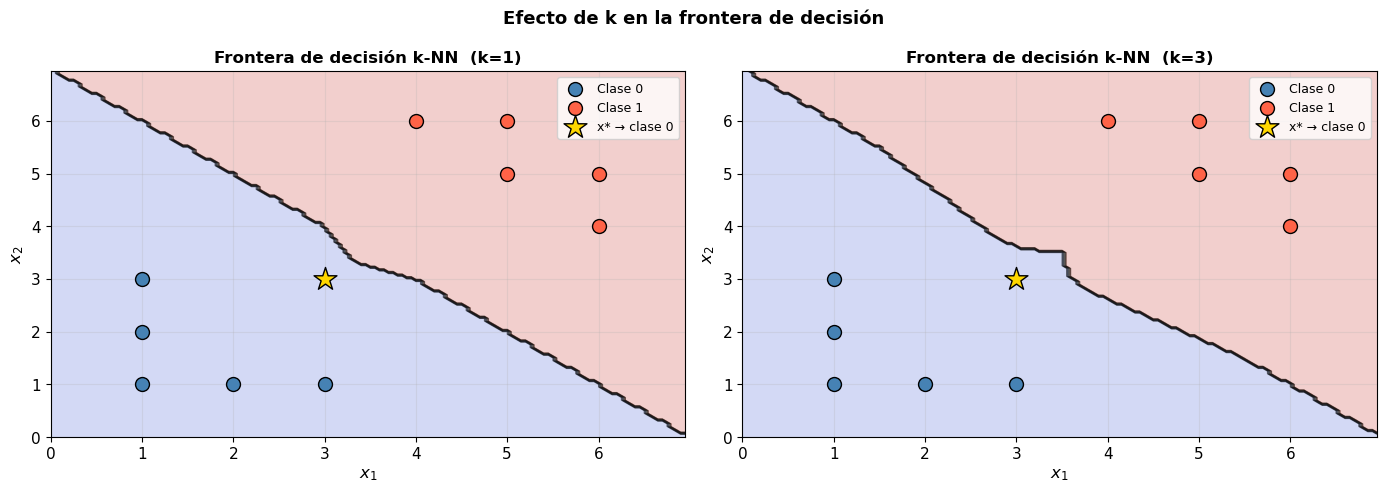

In [25]:
# Visualización: frontera de decisión k-NN Clasificación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, k_val in zip(axes, [1, 3]):
    knn_vis = KNeighborsClassifier(n_neighbors=k_val)
    knn_vis.fit(X_cls, y_cls)

    h  = 0.05
    x1 = np.arange(X_cls[:,0].min()-1, X_cls[:,0].max()+1, h)
    x2 = np.arange(X_cls[:,1].min()-1, X_cls[:,1].max()+1, h)
    xx1, xx2 = np.meshgrid(x1, x2)
    Z = knn_vis.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)

    ax.contourf(xx1, xx2, Z, alpha=0.25, cmap='coolwarm')
    ax.contour(xx1, xx2, Z, colors='k', linewidths=0.8, alpha=0.5)
    ax.scatter(X_cls[y_cls==0,0], X_cls[y_cls==0,1],
               c='steelblue', s=100, edgecolors='k', label='Clase 0', zorder=5)
    ax.scatter(X_cls[y_cls==1,0], X_cls[y_cls==1,1],
               c='tomato',    s=100, edgecolors='k', label='Clase 1', zorder=5)
    ax.scatter(*x_nuevo_cls, marker='*', s=300, color='gold',
               edgecolors='k', zorder=6, label=f'x* → clase {knn_vis.predict(x_nuevo_cls.reshape(1,-1))[0]}')
    ax.set_title(f'Frontera de decisión k-NN  (k={k_val})', fontsize=12, fontweight='bold')
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle('Efecto de k en la frontera de decisión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('knn_frontera_decision.png', dpi=200, bbox_inches='tight')
plt.show()

## 10. Aplicación de DOE para la selección del hiperparámetro $k$

El valor de $k$ en k-NN es un **hiperparámetro**: no se aprende de los datos,
sino que debe especificarse antes del entrenamiento. La elección de $k$ afecta
de manera importante el rendimiento predictivo del modelo.

Se puede tratar la selección de $k$ como un experimento con un solo factor:

| Elemento DOE | Descripción |
|---|---|
| Factor | $k$ (número de vecinos) |
| Niveles | $k \in \{1, 3, 5, 7, 9, 11, 15\}$ |
| Variable respuesta (regresión) | Error Absoluto Medio (MAE) |
| Variable respuesta (clasificación) | Accuracy |
| Repeticiones | Validación cruzada de $v=5$ folds |

**Nota sobre repeticiones.** La validación cruzada de $v$ folds divide el conjunto de
entrenamiento en $v$ subconjuntos disjuntos. En cada repetición se entrena con $v-1$
subconjuntos y se evalúa en el restante. Esto permite estimar la variabilidad del
error de predicción, análogamente a las repeticiones en DOE clásico.

La métrica promedio $\bar{e}_k$ y su desviación estándar $s_k$ a través de los
$v$ folds proveen estimaciones del desempeño esperado y su incertidumbre:

$$\bar{e}_k = \frac{1}{v}\sum_{j=1}^v e_{kj}, \qquad
s_k = \sqrt{\frac{1}{v-1}\sum_{j=1}^v (e_{kj} - \bar{e}_k)^2}$$

In [26]:
# Generar datos para el experimento
np.random.seed(42)
n_obs  = 120
X_exp  = np.column_stack([
    np.random.uniform(150, 210, n_obs),  # temperatura
    np.random.uniform(3,   8,   n_obs),  # presión
])

# Respuesta: relación no lineal para que k pequeño no sea siempre óptimo
y_exp = (
    0.15 * (X_exp[:,0] - 180)**2 / 100 * (-1) +
    3.0  * X_exp[:,1] +
    np.random.normal(0, 2, n_obs)
)

scaler_exp = StandardScaler()
X_exp_sc   = scaler_exp.fit_transform(X_exp)

print('Datos generados para el experimento DOE sobre k')
print(f'  n = {n_obs} observaciones')
print(f'  p = {X_exp.shape[1]} variables (temperatura, presión)')
print(f'  Validación cruzada: 5 folds')

Datos generados para el experimento DOE sobre k
  n = 120 observaciones
  p = 2 variables (temperatura, presión)
  Validación cruzada: 5 folds


In [27]:
from sklearn.model_selection import cross_val_score

# DISEÑO DE EXPERIMENTOS: factor k con 7 niveles
k_niveles = [1, 3, 5, 7, 9, 11, 15]
v_folds   = 5
resultados = []

print(f'Experimento de un factor: k-NN Regresión')
print(f'Factor: k   Niveles: {k_niveles}   Repeticiones: {v_folds}-fold CV')
print()
print(f'{'k':>5} | {'MAE promedio':>14} | {'Desv. Std':>12} | {'IC 95% (±)':>12}')
print('-' * 52)

for k in k_niveles:
    knn_r = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
    scores = -cross_val_score(knn_r, X_exp_sc, y_exp,
                               cv=v_folds, scoring='neg_mean_absolute_error')
    media = scores.mean()
    std   = scores.std(ddof=1)
    ic    = 1.96 * std / np.sqrt(v_folds)  # IC aproximado
    resultados.append({'k': k, 'MAE': media, 'Std': std, 'IC': ic})
    print(f'{k:>5} | {media:>14.4f} | {std:>12.4f} | {ic:>12.4f}')

df_doe = pd.DataFrame(resultados)
k_opt  = int(df_doe.loc[df_doe['MAE'].idxmin(), 'k'])
print()
print(f'k óptimo según MAE mínimo: k = {k_opt}')

Experimento de un factor: k-NN Regresión
Factor: k   Niveles: [1, 3, 5, 7, 9, 11, 15]   Repeticiones: 5-fold CV

    k |   MAE promedio |    Desv. Std |   IC 95% (±)
----------------------------------------------------
    1 |         2.3547 |       0.3376 |       0.2960
    3 |         1.9486 |       0.0909 |       0.0797
    5 |         1.9528 |       0.1420 |       0.1244
    7 |         1.8907 |       0.0957 |       0.0839
    9 |         1.8901 |       0.1082 |       0.0949
   11 |         1.9335 |       0.0827 |       0.0725
   15 |         1.9518 |       0.1623 |       0.1423

k óptimo según MAE mínimo: k = 9


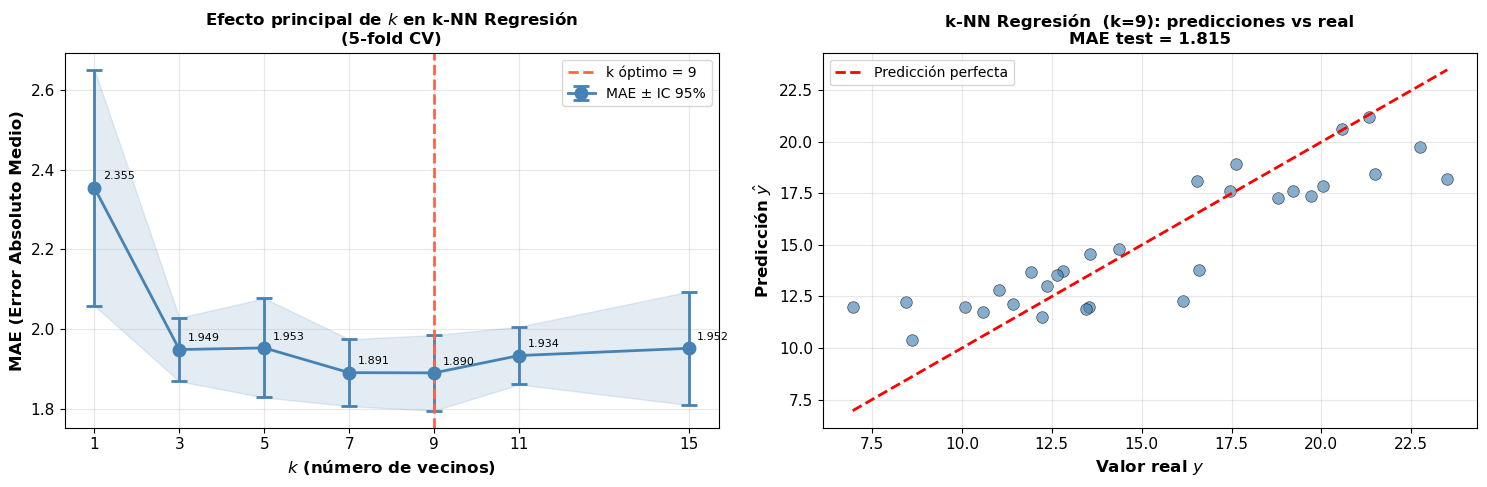

In [28]:
# Gráfica principal del experimento DOE
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: MAE vs k con IC
ax1 = axes[0]
ax1.errorbar(df_doe['k'], df_doe['MAE'], yerr=df_doe['IC'],
             marker='o', markersize=9, linewidth=2, color='steelblue',
             capsize=6, capthick=2, ecolor='steelblue', label='MAE ± IC 95%')
ax1.axvline(k_opt, color='tomato', linestyle='--', lw=2, label=f'k óptimo = {k_opt}')
ax1.fill_between(df_doe['k'], df_doe['MAE']-df_doe['IC'],
                 df_doe['MAE']+df_doe['IC'], alpha=0.15, color='steelblue')
ax1.set_xlabel('$k$ (número de vecinos)', fontsize=12, fontweight='bold')
ax1.set_ylabel('MAE (Error Absoluto Medio)', fontsize=12, fontweight='bold')
ax1.set_title('Efecto principal de $k$ en k-NN Regresión\n(5-fold CV)', fontsize=12, fontweight='bold')
ax1.set_xticks(k_niveles)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

for _, row in df_doe.iterrows():
    ax1.annotate(f'{row["MAE"]:.3f}', (row['k'], row['MAE']),
                 textcoords='offset points', xytext=(6, 6), fontsize=8)

# Gráfica 2: predicciones del modelo óptimo vs valores reales
ax2 = axes[1]
knn_opt = KNeighborsRegressor(n_neighbors=k_opt)
X_tr, X_te, y_tr, y_te = train_test_split(X_exp_sc, y_exp, test_size=0.25, random_state=42)
knn_opt.fit(X_tr, y_tr)
y_hat = knn_opt.predict(X_te)

mae_test = mean_absolute_error(y_te, y_hat)
ax2.scatter(y_te, y_hat, alpha=0.65, s=70, color='steelblue', edgecolors='k', lw=0.5)
mn, mx = min(y_te.min(), y_hat.min()), max(y_te.max(), y_hat.max())
ax2.plot([mn,mx],[mn,mx], 'r--', lw=2, label='Predicción perfecta')
ax2.set_xlabel('Valor real $y$', fontsize=12, fontweight='bold')
ax2.set_ylabel('Predicción $\\hat{y}$', fontsize=12, fontweight='bold')
ax2.set_title(f'k-NN Regresión  (k={k_opt}): predicciones vs real\nMAE test = {mae_test:.3f}',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('doe_knn_regresion.png', dpi=200, bbox_inches='tight')
plt.show()

### 10.1 DOE para k-NN Clasificación

Se repite el experimento para el caso de clasificación binaria,
utilizando Accuracy como variable respuesta.

In [29]:
np.random.seed(42)
n_cls   = 120
X_cls2  = np.column_stack([
    np.random.uniform(150, 210, n_cls),
    np.random.uniform(3,   8,   n_cls),
])
y_cls2 = (
    (0.15*(X_cls2[:,0]-180)**2/100*(-1) + 3*X_cls2[:,1] + np.random.normal(0,2,n_cls))
    > np.median(0.15*(X_cls2[:,0]-180)**2/100*(-1) + 3*X_cls2[:,1])
).astype(int)

scaler_cls2 = StandardScaler()
X_cls2_sc   = scaler_cls2.fit_transform(X_cls2)

resultados_cls = []

print('Experimento DOE: k-NN Clasificación')
print()
print(f'{'k':>5} | {'Accuracy':>12} | {'Desv. Std':>12} | {'IC 95% (±)':>12}')
print('-' * 50)

for k in k_niveles:
    knn_c  = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores = cross_val_score(knn_c, X_cls2_sc, y_cls2, cv=v_folds, scoring='accuracy')
    media  = scores.mean()
    std    = scores.std(ddof=1)
    ic     = 1.96 * std / np.sqrt(v_folds)
    resultados_cls.append({'k': k, 'Accuracy': media, 'Std': std, 'IC': ic})
    print(f'{k:>5} | {media:>12.4f} | {std:>12.4f} | {ic:>12.4f}')

df_cls = pd.DataFrame(resultados_cls)
k_opt_cls = int(df_cls.loc[df_cls['Accuracy'].idxmax(), 'k'])
print()
print(f'k óptimo según Accuracy máxima: k = {k_opt_cls}')

Experimento DOE: k-NN Clasificación

    k |     Accuracy |    Desv. Std |   IC 95% (±)
--------------------------------------------------
    1 |       0.8250 |       0.0618 |       0.0542
    3 |       0.8667 |       0.0685 |       0.0600
    5 |       0.8750 |       0.0417 |       0.0365
    7 |       0.8833 |       0.0349 |       0.0306
    9 |       0.8667 |       0.0543 |       0.0476
   11 |       0.8917 |       0.0373 |       0.0327
   15 |       0.9000 |       0.0228 |       0.0200

k óptimo según Accuracy máxima: k = 15


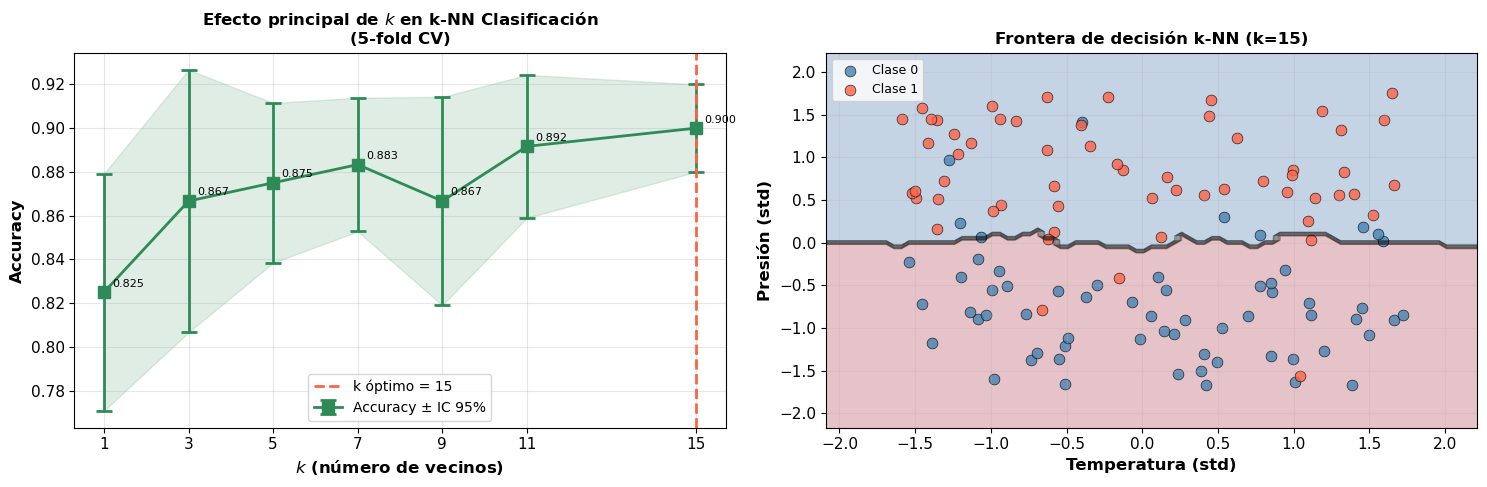

In [30]:
# Gráfica DOE clasificación
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: Accuracy vs k
ax1 = axes[0]
ax1.errorbar(df_cls['k'], df_cls['Accuracy'], yerr=df_cls['IC'],
             marker='s', markersize=9, linewidth=2, color='seagreen',
             capsize=6, capthick=2, ecolor='seagreen', label='Accuracy ± IC 95%')
ax1.axvline(k_opt_cls, color='tomato', linestyle='--', lw=2,
            label=f'k óptimo = {k_opt_cls}')
ax1.fill_between(df_cls['k'],
                 df_cls['Accuracy']-df_cls['IC'],
                 df_cls['Accuracy']+df_cls['IC'],
                 alpha=0.15, color='seagreen')
ax1.set_xlabel('$k$ (número de vecinos)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Efecto principal de $k$ en k-NN Clasificación\n(5-fold CV)',
              fontsize=12, fontweight='bold')
ax1.set_xticks(k_niveles)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
for _, row in df_cls.iterrows():
    ax1.annotate(f'{row["Accuracy"]:.3f}', (row['k'], row['Accuracy']),
                 textcoords='offset points', xytext=(6, 4), fontsize=8)

# Gráfica 2: Frontera de decisión k óptimo
ax2 = axes[1]
knn_opt_cls = KNeighborsClassifier(n_neighbors=k_opt_cls)
knn_opt_cls.fit(X_cls2_sc, y_cls2)

h   = 0.05
x1r = np.arange(X_cls2_sc[:,0].min()-0.5, X_cls2_sc[:,0].max()+0.5, h)
x2r = np.arange(X_cls2_sc[:,1].min()-0.5, X_cls2_sc[:,1].max()+0.5, h)
xx1, xx2 = np.meshgrid(x1r, x2r)
Z = knn_opt_cls.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)

ax2.contourf(xx1, xx2, Z, alpha=0.25, cmap='RdBu')
ax2.contour(xx1, xx2, Z, colors='k', linewidths=0.8, alpha=0.4)
ax2.scatter(X_cls2_sc[y_cls2==0,0], X_cls2_sc[y_cls2==0,1],
            c='steelblue', s=60, edgecolors='k', lw=0.5, label='Clase 0', alpha=0.8)
ax2.scatter(X_cls2_sc[y_cls2==1,0], X_cls2_sc[y_cls2==1,1],
            c='tomato', s=60, edgecolors='k', lw=0.5, label='Clase 1', alpha=0.8)
ax2.set_xlabel('Temperatura (std)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Presión (std)', fontsize=12, fontweight='bold')
ax2.set_title(f'Frontera de decisión k-NN (k={k_opt_cls})', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('doe_knn_clasificacion.png', dpi=200, bbox_inches='tight')
plt.show()

## Tabla entregable

### Regresión (métrica: MAE — menor es mejor)

| $k$ | MAE promedio | Desv. Std | IC 95% (±) |
|-----|-------------|-----------|------------|
| 1  |  |  |  |
| 3  |  |  |  |
| 5  |  |  |  |
| 7  |  |  |  |
| 9  |  |  |  |
| 11 |  |  |  |
| 15 |  |  |  |

### Clasificación (métrica: Accuracy — mayor es mejor)

| $k$ | Accuracy | Desv. Std | IC 95% (±) |
|-----|----------|-----------|------------|
| 1  |  |  |  |
| 3  |  |  |  |
| 5  |  |  |  |
| 7  |  |  |  |
| 9  |  |  |  |
| 11 |  |  |  |
| 15 |  |  |  |

**Preguntas de análisis:**

1. ¿Cuál es el valor de $k$ óptimo para regresión y para clasificación? ¿Coinciden?
2. ¿Cómo varía el IC 95% a medida que $k$ aumenta? ¿Qué indica esto sobre la estabilidad?
3. ¿Qué ocurre con el MAE cuando $k = 1$? ¿Y cuando $k = 15$? ¿A qué se debe?

## Ejercicio final

Repitan el experimento DOE anterior para k-NN Regresión **sin aplicar escalamiento**
(utilizando `X_exp` en lugar de `X_exp_sc`) y completen la siguiente tabla comparativa:

| $k$ | MAE (con escalamiento) | MAE (sin escalamiento) |
|-----|------------------------|------------------------|
| 1  |  |  |
| 3  |  |  |
| 5  |  |  |
| 7  |  |  |
| 9  |  |  |
| 11 |  |  |
| 15 |  |  |

**Pregunta:** ¿El escalamiento modifica el $k$ óptimo? ¿Por qué?

## Conclusiones

1. Un vector $x \in \mathbb{R}^p$ representa una observación con $p$ variables medidas.
2. Las normas $L_1$, $L_2$ y $L_\infty$ cuantifican la magnitud de un vector;
   satisfacen $\|x\|_\infty \leq \|x\|_2 \leq \|x\|_1$.
3. Toda norma induce una métrica; las más usadas en k-NN son $d_2$ y $d_1$.
4. El producto punto $x^Ty = \|x\|_2\|y\|_2\cos\theta$ mide alineación direccional;
   es la operación fundamental en capas lineales de redes neuronales.
5. Una base de datos de $n$ observaciones y $p$ variables es una matriz
   $X \in \mathbb{R}^{n \times p}$.
6. El escalamiento es necesario cuando las variables tienen magnitudes heterogéneas,
   para que ninguna variable domine las distancias.
7. El algoritmo k-NN predice mediante los $k$ vecinos más cercanos:
   promedio de respuestas (regresión) o clase mayoritaria (clasificación).
8. El hiperparámetro $k$ puede seleccionarse mediante un diseño de experimentos
   de un factor, usando validación cruzada como mecanismo de repetición.